# California Real Estate — Exploratory Data Analysis

**Data Source:** CRMLS (California Regional Multiple Listing Service) via CoreLogic Trestle API  
**Coverage:** January 2024 — March 2026 (27 months)  
**Datasets:**
- `priceratio.csv` — Closed residential transactions with derived market metrics
- `newlistings.csv` — New residential listings

**Objective:** Identify meaningful patterns and relationships in the California housing market to inform the construction of market analysis and competitive analysis Tableau dashboards.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Add project root to path so we can import our modules
sys.path.insert(0, os.path.abspath('..'))

from data_cleaning.helpers.duplicates import drop_duplicate_columns
from data_cleaning.helpers.dates import parse_sold_dates, parse_listing_dates
from data_cleaning.helpers.missing import missing_value_report
from data_cleaning.helpers.outliers import flag_outliers, filter_outliers
from data_cleaning.helpers.mortgage_rates import load_mortgage_rates, merge_mortgage_rates

from feature_engineering.helpers.engineer_features import (
    add_market_condition, add_price_reduction_flags,
    add_dom_buckets, add_price_tiers
)
from feature_engineering.add_new_features import engineer_sold_features, engineer_listing_features

from exploratory_analysis.helpers.visualize import (
    plot_missing_values, plot_boxplots, plot_sold_distributions,
    plot_listing_distributions, plot_monthly_kpi_trends, plot_yoy_comparison,
    plot_supply_vs_demand, plot_top_counties, plot_top_cities,
    plot_subtype_comparison, plot_price_vs_size, plot_dom_bucket_analysis,
    plot_price_reductions, plot_top_offices, plot_top_agents,
    plot_correlation_heatmap, plot_close_vs_list, plot_price_tiers,
    plot_new_construction
)
from exploratory_analysis.helpers.stats import (
    monthly_sold_summary, monthly_listing_summary, geographic_summary,
    dom_bucket_summary, competitive_summary, price_tier_summary,
    percentile_summary, market_summary
)

---
## 1. Load Data


In [2]:
sold = pd.read_csv('../data/priceratio.csv', encoding='ISO-8859-1')
listings = pd.read_csv('../data/newlistings.csv', encoding='ISO-8859-1')

print(f"Sold transactions: {sold.shape[0]:,} rows x {sold.shape[1]} columns")
print(f"New listings:      {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Sold transactions: 382,247 rows x 46 columns
New listings:      514,182 rows x 84 columns


### Property Type Breakdown

Document the unique property types in each dataset before filtering.


In [3]:
# Unique property types in sold data
if 'PropertyType' in sold.columns:
    print('=== Sold — Property Types ===')
    print(sold['PropertyType'].value_counts())
    print(f'\nTotal unique: {sold["PropertyType"].nunique()}')
else:
    print('PropertyType column not found — dataset is pre-filtered to Residential')

if 'PropertyType' in listings.columns:
    print('\n=== Listings — Property Types ===')
    print(listings['PropertyType'].value_counts())
    print(f'\nTotal unique: {listings["PropertyType"].nunique()}')
else:
    print('PropertyType column not found — dataset is pre-filtered to Residential')


=== Sold — Property Types ===
PropertyType
Residential    382247
Name: count, dtype: int64

Total unique: 1

=== Listings — Property Types ===
PropertyType
Residential    514182
Name: count, dtype: int64

Total unique: 1


---
## 2. Data Overview

Inspect schema, data types, and summary statistics for both datasets.


In [4]:
print("=== Sold Transactions (priceratio.csv) ===")
print(f"Columns: {sold.columns.tolist()}")
sold.info()

=== Sold Transactions (priceratio.csv) ===
Columns: ['OriginalListPrice', 'ListingKey', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'CountyOrParish', 'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'YearBuilt', 'ListingId', 'BathroomsTotalInteger', 'City', 'BuildingAreaTotal', 'BedroomsTotal', 'StateOrProvince', 'CoveredSpaces', 'Stories', 'Levels', 'LotSizeDimensions', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces', 'PostalCode', 'LotSizeSquareFeet', 'OriginatingSystemName', 'OriginatingSystemSubName', 'priceratio', 'pricesqft']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382247 entries, 0 to 382246
Data columns (total 46 columns):
 #   Column                    Non-Null

In [5]:
sold.describe()


,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,ParkingTotal,LotSizeAcres,YearBuilt,BathroomsTotalInteger,BuildingAreaTotal,BedroomsTotal,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,LotSizeSquareFeet,priceratio,pricesqft
count,381559.00,382247.00,382245.00,378313.00,378313.00,382022.00,382247.00,354897.00,0.00,381817.00,351963.00,381899.00,382179.00,26688.00,382236.00,0.00,322822.00,352443.00,221655.00,365864.00,352324.00,346035.00,382020.00
mean,1226265.35,1093801384.20,1183111.38,34.71,-118.64,1905.12,1137951.88,27.30,NaN,9.59,70.08,1978.53,2.53,2116.48,3.20,NaN,1.36,38745.46,2.06,1.86,332147.77,0.99,inf
std,6904964.21,28500386.54,5883557.14,1.74,2.98,27554.58,1350062.66,27.82,NaN,4197.63,16652.52,26.27,1.14,1707.54,1.07,NaN,0.48,2181884.46,7.38,3.72,16159168.72,0.05,NaN
min,0.00,421678487.00,0.00,-117.47,-177.65,0.00,525.00,-65.00,NaN,-143.00,0.00,1776.00,0.00,0.00,0.00,NaN,1.00,0.00,0.00,0.00,0.00,0.83,0.00
25%,585000.00,1073314538.50,575000.00,33.74,-119.17,1246.00,576000.00,7.00,NaN,2.00,0.12,1960.00,2.00,1270.00,3.00,NaN,1.00,5000.00,1.00,2.00,5227.00,0.96,368.81
50%,825000.00,1090538919.00,821000.00,34.06,-118.04,1640.00,815000.00,16.00,NaN,2.00,0.17,1979.00,2.00,1712.50,3.00,NaN,1.00,7013.00,2.00,2.00,7236.00,1.00,537.69
75%,1299000.00,1114254398.50,1300000.00,34.73,-117.27,2216.00,1294000.00,40.00,NaN,3.00,0.27,1999.00,3.00,2456.25,4.00,NaN,2.00,10890.00,3.00,2.00,11770.00,1.02,732.67
max,1390000000.00,1155620121.00,989500000.00,56.13,329.00,17021321.00,137500000.00,168.00,NaN,2593669.00,7810698.36,2026.00,175.00,123764.00,45.00,NaN,2.00,918742280.00,3333.00,600.00,2208317760.00,1.15,inf


In [6]:
print("=== New Listings (newlistings.csv) ===")
print(f"Columns: {listings.columns.tolist()}")
listings.info()

=== New Listings (newlistings.csv) ===
Columns: ['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus', 'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1', 'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1', 'ListingId', 'BathroomsTotalInteger', 'City', 'BuyerAgencyCompensation', 'TaxYear', 'Buildi

In [7]:
listings.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,ListingKeyNumeric,TaxAnnualAmount,ParkingTotal,LotSizeAcres,YearBuilt,DaysOnMarket.1,StreetNumberNumeric,LivingArea.1,BathroomsTotalInteger,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,Longitude.1,ElementarySchoolDistrict,BelowGradeFinishedArea,BusinessType,Latitude.1,ListPrice.1,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,513447.00,514182.00,145855.00,434335.00,434335.00,513656.00,514182.00,514182.00,0.00,0.00,514182.00,0.00,514162.00,471786.00,513309.00,514182.00,513390.00,513656.00,514127.00,78993.00,0.00,45572.00,514049.00,434335.00,0.00,2856.00,0.00,434335.00,514182.00,0.00,424901.00,472585.00,280211.00,485699.00,390710.00,472416.00,0.00
mean,1396197.53,1102248796.84,1196611.44,34.59,-118.45,1980.11,1310238.66,20.05,NaN,NaN,1102248796.84,NaN,7.86,65.98,1979.53,20.05,11573.71,1980.11,2.62,189.11,NaN,2439.41,3.22,-118.45,NaN,86.79,NaN,34.59,1310238.66,NaN,1.37,47179.74,2.05,1.85,269.43,410696.60,NaN
std,7441658.40,28338091.66,4285442.05,2.01,3.47,23964.85,2349986.14,27.34,NaN,NaN,28338091.66,NaN,3617.29,12409.20,26.98,27.34,285923.58,23964.85,3.33,2340.72,NaN,2251.44,1.18,3.47,NaN,361.49,NaN,2.01,2349986.14,NaN,0.48,2225516.97,6.59,3.88,2423.71,20878085.59,NaN
min,0.00,1018357250.00,525.00,-117.47,-159.48,0.00,100.00,-58.00,NaN,NaN,1018357250.00,NaN,-143.00,0.00,1776.00,-58.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,-159.48,NaN,0.00,NaN,-117.47,100.00,NaN,1.00,0.00,0.00,0.00,0.00,0.00,NaN
25%,585000.00,1077035641.00,600000.00,33.74,-118.65,1246.00,580000.00,5.00,NaN,NaN,1077035641.00,NaN,2.00,0.12,1961.00,5.00,977.00,1246.00,2.00,2.00,NaN,1305.00,2.00,-118.65,NaN,0.00,NaN,33.74,580000.00,NaN,1.00,5000.00,1.00,1.00,0.00,5227.00,NaN
50%,849000.00,1103158605.50,850000.00,34.05,-118.02,1668.00,839950.00,11.00,NaN,NaN,1103158605.50,NaN,2.00,0.17,1980.00,11.00,3269.00,1668.00,2.00,2.50,NaN,1822.00,3.00,-118.02,NaN,0.00,NaN,34.05,839950.00,NaN,1.00,7193.00,2.00,2.00,125.00,7405.00,NaN
75%,1387500.00,1118957054.50,1350000.00,34.46,-117.24,2297.00,1375000.00,23.00,NaN,NaN,1118957054.50,NaN,3.00,0.31,2001.00,23.00,12059.00,2297.00,3.00,2.50,NaN,2789.00,4.00,-117.24,NaN,0.00,NaN,34.46,1375000.00,NaN,2.00,12000.00,3.00,2.00,400.00,13520.00,NaN
max,1390000000.00,1156084894.00,820000000.00,737.00,329.00,17021321.00,195000000.00,731.00,NaN,NaN,1156084894.00,NaN,2593669.00,4187292.00,2028.00,731.00,79547958.00,17021321.00,2208.00,200000.00,NaN,123764.00,94.00,329.00,NaN,5000.00,NaN,737.00,195000000.00,NaN,2.00,918742280.00,3333.00,600.00,968348.00,7638115320.00,NaN


---
## 3. Data Cleaning

### 3a. Handle Duplicate Columns in Listings

The  file contains duplicate column names from the API extraction. These are redundant and should be dropped before analysis.


In [8]:
listings = drop_duplicate_columns(listings)

Duplicate columns to drop (11):
['PropertyType.1', 'ListAgentFirstName.1', 'DaysOnMarket.1', 'LivingArea.1', 'Longitude.1', 'Latitude.1', 'ListPrice.1', 'ListAgentLastName.1', 'CloseDate.1', 'BuyerOfficeName.1', 'UnparsedAddress.1']

Shape after dropping duplicates: (514182, 73)


### 3b. Parse Date Columns and Create Time Features

In [9]:
sold = parse_sold_dates(sold)
listings = parse_listing_dates(listings)

Sold date range: 2024-01-01 to 2026-02-28
Listings date range: 2024-01-01 to 2026-02-28


### 3e. Mortgage Rate Enrichment

Merge the 30-year fixed mortgage rate (FRED MORTGAGE30US) onto both datasets.
Weekly rates are resampled to monthly averages and joined on a year-month key.


In [10]:
mortgage_monthly = load_mortgage_rates('../data/MORTGAGE30US.csv')

sold = merge_mortgage_rates(sold, mortgage_monthly, date_col='CloseDate')
listings = merge_mortgage_rates(listings, mortgage_monthly, date_col='ListingContractDate')

# Preview the merge
print(sold[['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']].head())


Mortgage rates loaded: 661 months (1971-04 to 2026-04)
Merged on CloseDate: 0 rows with null rate (0.00%)
Merged on ListingContractDate: 0 rows with null rate (0.00%)
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-01-26    2024-01   240000.00             6.64
1 2024-01-05    2024-01   815000.00             6.64
2 2024-01-05    2024-01   810000.00             6.64
3 2024-01-02    2024-01  2100000.00             6.64
4 2024-01-22    2024-01  1950000.00             6.64


In [11]:
# Save enriched datasets with mortgage rates
sold.to_csv('../data/mortgage_enriched/sold_with_rates.csv', index=False)
listings.to_csv('../data/mortgage_enriched/listings_with_rates.csv', index=False)

print(f'Saved sold_with_rates.csv: {sold.shape[0]:,} rows')
print(f'Saved listings_with_rates.csv: {listings.shape[0]:,} rows')


Saved sold_with_rates.csv: 382,247 rows
Saved listings_with_rates.csv: 514,182 rows


### 3c. Missing Data Analysis

In [12]:
sold_missing = missing_value_report(sold, "Sold Transactions")

=== Sold Transactions: 38 columns with missing values ===
                          Missing Count  Missing %
FireplacesTotal                  382247     100.00
CoveredSpaces                    382247     100.00
LotSizeDimensions                363661      95.14
OriginatingSystemSubName         359462      94.04
OriginatingSystemName            359462      94.04
BuildingAreaTotal                355559      93.02
CoListOfficeName                 291851      76.35
SubdivisionName                  240504      62.92
MainLevelBedrooms                160592      42.01
Stories                           59425      15.55
AttachedGarageYN                  58332      15.26
Levels                            37342       9.77
priceratio                        36212       9.47
LotSizeAcres                      30284       7.92
LotSizeSquareFeet                 29923       7.83
LotSizeArea                       29804       7.80
NewConstructionYN                 28303       7.40
DaysOnMarket            

In [13]:
list_missing = missing_value_report(listings, "New Listings")

=== New Listings: 63 columns with missing values ===
                              Missing Count  Missing %
MiddleOrJuniorSchoolDistrict         514182     100.00
FireplacesTotal                      514182     100.00
CoveredSpaces                        514182     100.00
BusinessType                         514182     100.00
ElementarySchoolDistrict             514182     100.00
...                                     ...        ...
StateOrProvince                          46       0.01
BathroomsTotalInteger                    55       0.01
ListAgentLastName                        42       0.01
ParkingTotal                             20       0.00
PostalCode                               13       0.00

[63 rows x 2 columns]


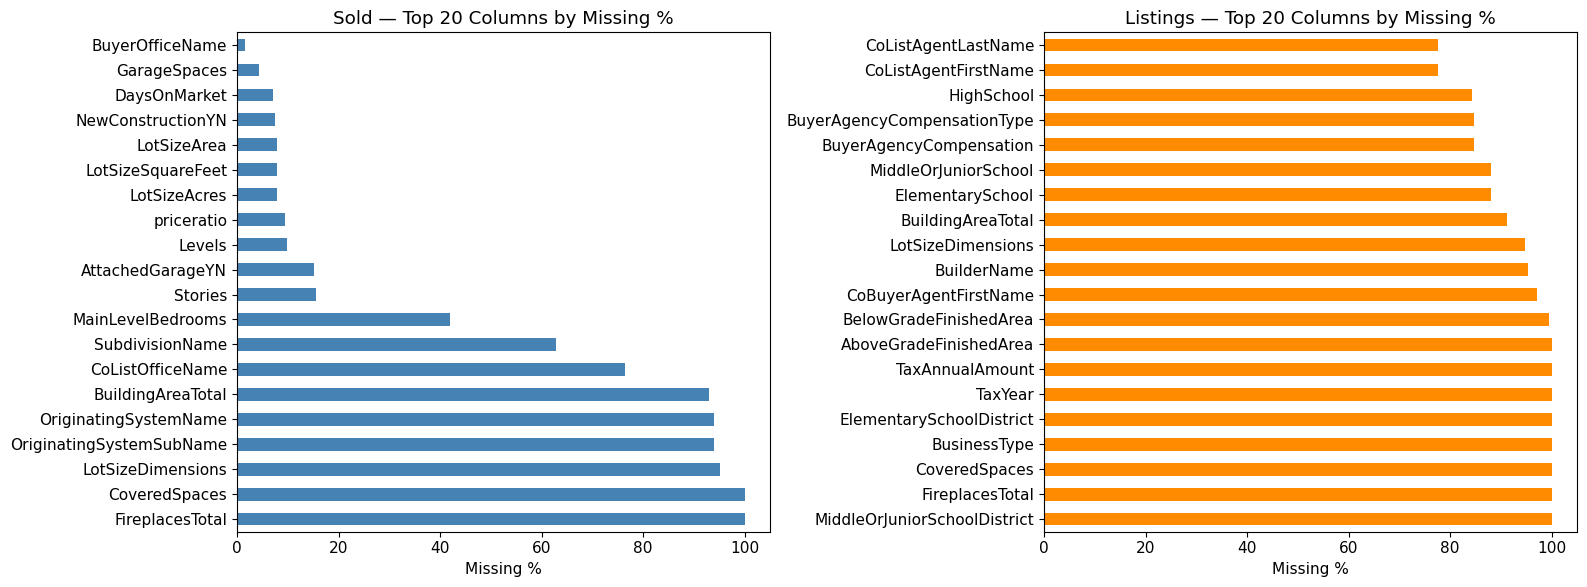

In [14]:
plot_missing_values(sold_missing, list_missing)

### 3d. Outlier Assessment

The  and  fields in the sold dataset already have IQR-based outlier handling applied (outliers replaced with NaN in ). Here we examine the remaining distributions for any additional anomalies in key numeric fields.


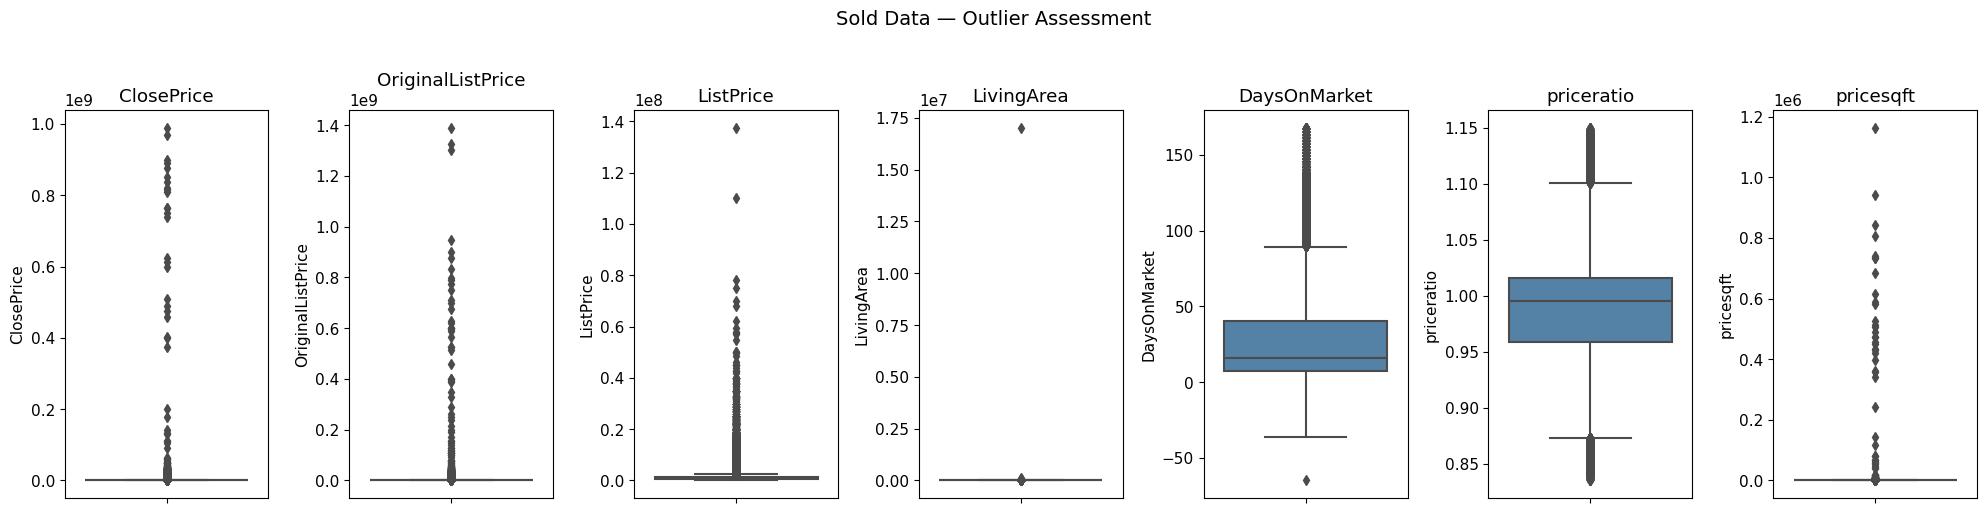

In [15]:
sold_numeric_cols = ['ClosePrice', 'OriginalListPrice', 'ListPrice', 'LivingArea',
                     'DaysOnMarket', 'priceratio', 'pricesqft']
plot_boxplots(sold, sold_numeric_cols, 'Sold Data — Outlier Assessment', color='steelblue')

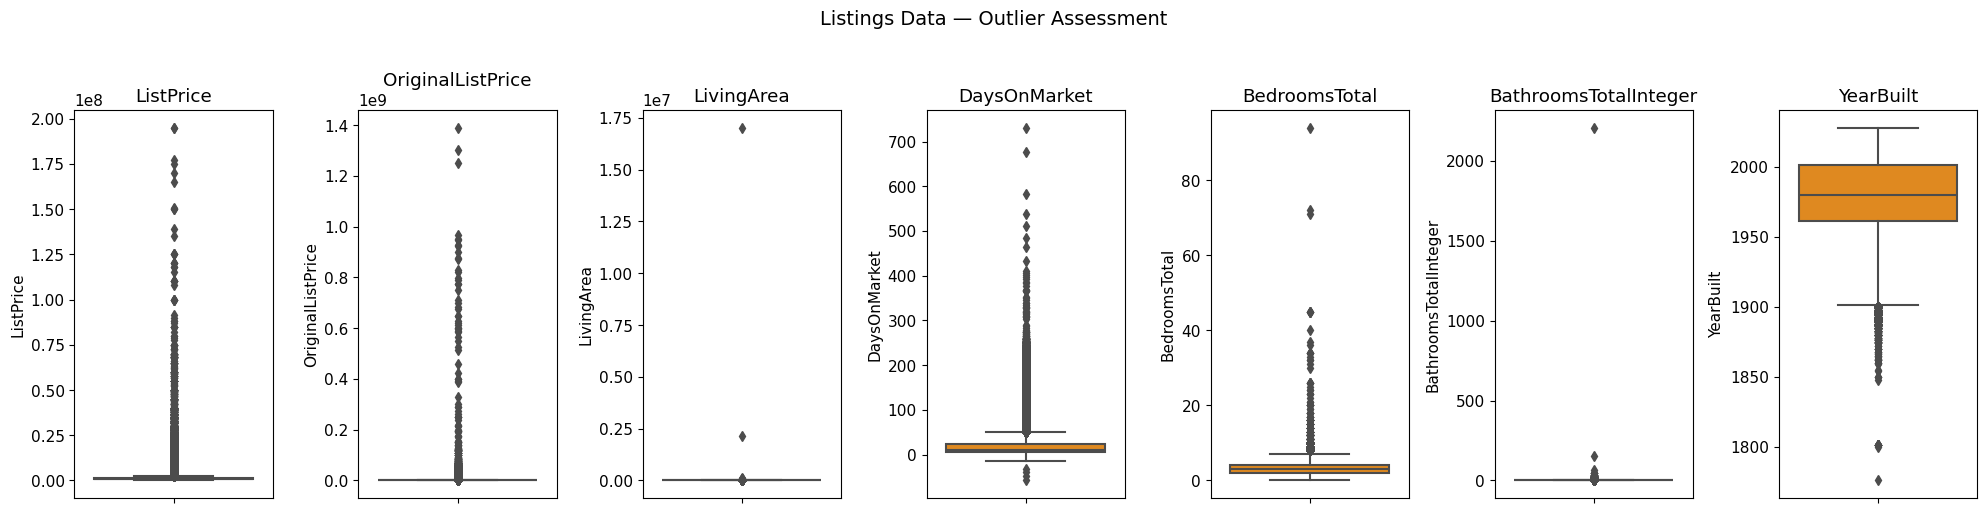

In [16]:
list_numeric_cols = ['ListPrice', 'OriginalListPrice', 'LivingArea', 'DaysOnMarket',
                     'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt']
plot_boxplots(listings, list_numeric_cols, 'Listings Data — Outlier Assessment', color='darkorange')

---
## 4. Distributions

Examine the shape of key numeric variables to understand skewness, central tendency, and spread. This informs whether we should use median vs. mean for aggregations and whether transformations are needed.


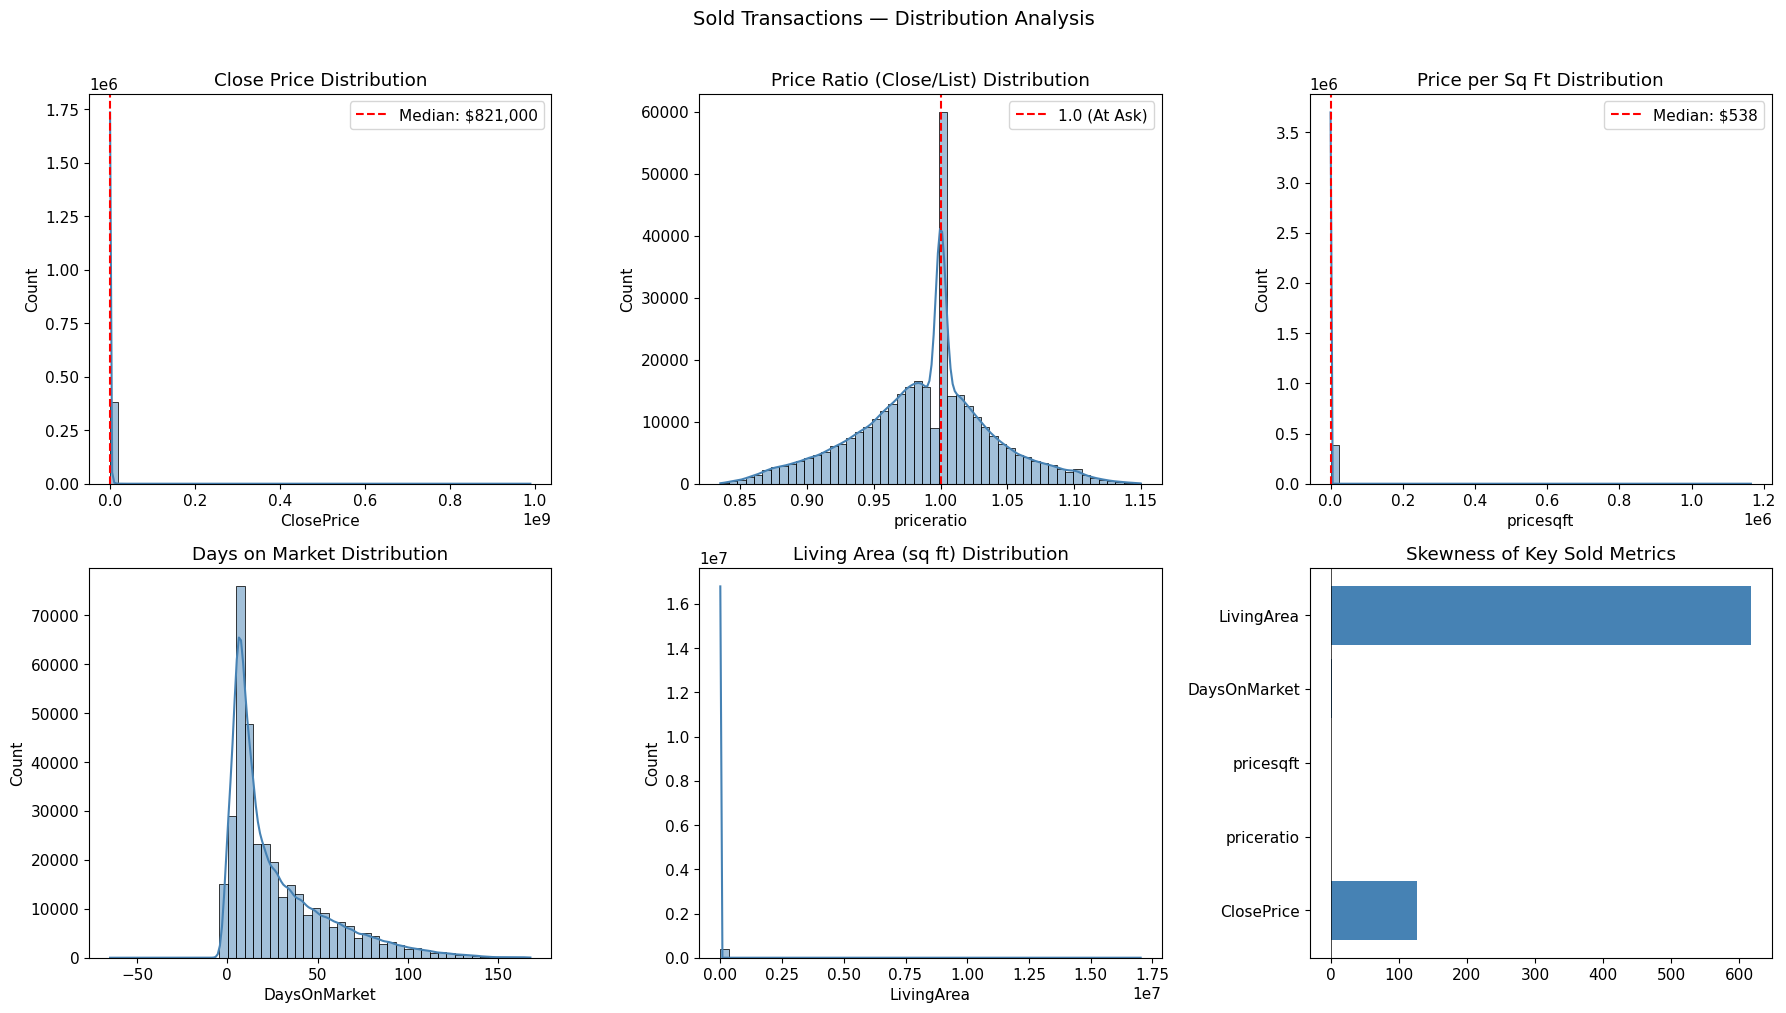

In [17]:
plot_sold_distributions(sold)

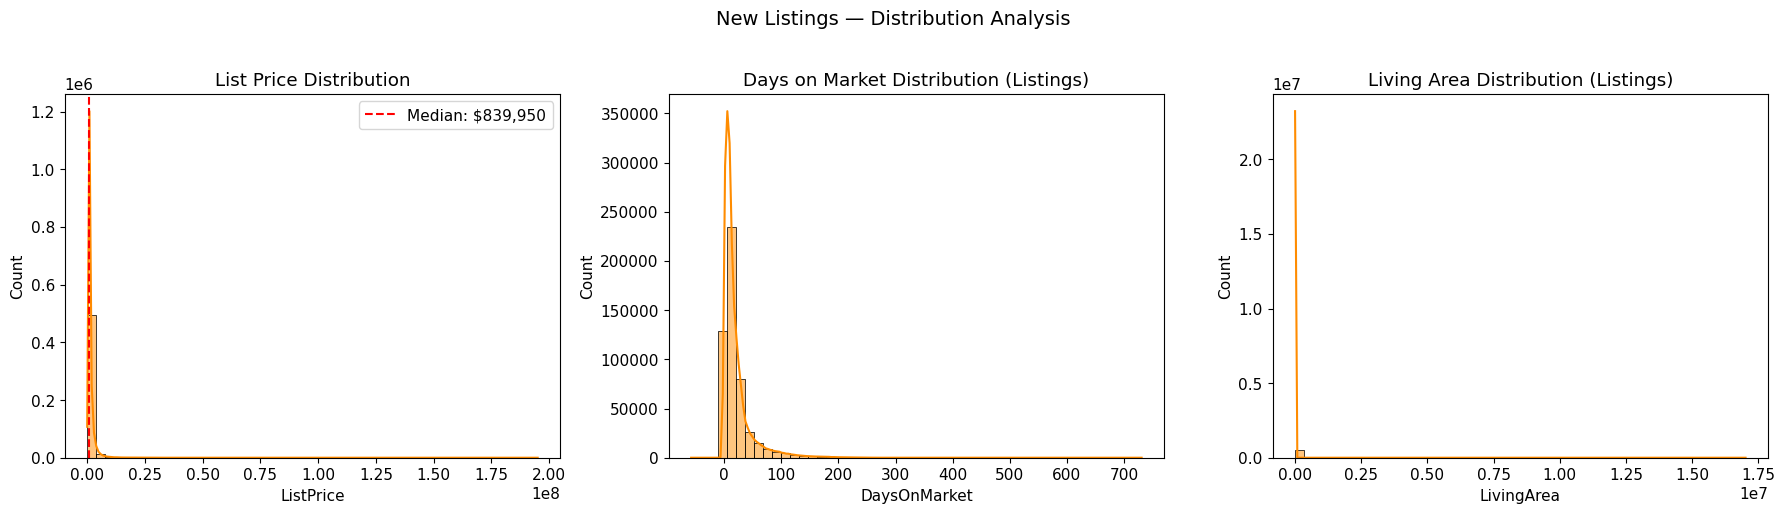

In [18]:
plot_listing_distributions(listings)

### Numeric Distribution Summary

Percentile table for key numeric fields


In [19]:
sold_percentiles = percentile_summary(sold, ['ClosePrice', 'LivingArea', 'DaysOnMarket'])
print('=== Sold Transactions — Numeric Distribution Summary ===')
print(sold_percentiles)
print()

list_percentiles = percentile_summary(listings, ['ListPrice', 'LivingArea', 'DaysOnMarket'])
print('=== New Listings — Numeric Distribution Summary ===')
print(list_percentiles)


=== Sold Transactions — Numeric Distribution Summary ===
                 Count    Min      25th    Median       Mean       75th  \
ClosePrice   382245.00   0.00 575000.00 821000.00 1183111.38 1300000.00   
LivingArea   382022.00   0.00   1246.00   1640.00    1905.12    2216.00   
DaysOnMarket 354897.00 -65.00      7.00     16.00      27.30      40.00   

                      Max  
ClosePrice   989500000.00  
LivingArea    17021321.00  
DaysOnMarket       168.00  

=== New Listings — Numeric Distribution Summary ===
                 Count    Min      25th    Median       Mean       75th  \
ListPrice    514182.00 100.00 580000.00 839950.00 1310238.66 1375000.00   
LivingArea   513656.00   0.00   1246.00   1668.00    1980.11    2297.00   
DaysOnMarket 514182.00 -58.00      5.00     11.00      20.05      23.00   

                      Max  
ListPrice    195000000.00  
LivingArea    17021321.00  
DaysOnMarket       731.00  


---
## 5. Feature Engineering

Create additional features that will be useful for both the EDA and the downstream Tableau dashboards.


In [23]:
sold = engineer_sold_features(sold)

--- Sold Data Features ---
Market condition: {"Buyer's Market": 213057, "Seller's Market": 169190}
Was reduced: {0: 278049, 1: 104198}
DOM buckets: {'0-7': 77821, '8-14': 74694, '15-30': 72445, '31-60': 68166, '61-90': 31463, '90+': 15167}
Price tiers: {'Under 300K': 13089, '300K-500K': 54536, '500K-750K': 98608, '750K-1M': 76159, '1M-2M': 100120, '2M+': 39732}


In [24]:
listings = engineer_listing_features(listings)

--- Listings Data Features ---
Was reduced: {0: 425421, 1: 88761}
Price tiers: {'Under 300K': 17517, '300K-500K': 75041, '500K-750K': 127845, '750K-1M': 100704, '1M-2M': 130310, '2M+': 62765}


---
## 6. Exploratory Data Analysis

### 6a. Market Trends Over Time

These monthly time-series views mirror the KPIs tracked in the CA Market Analysis Tableau dashboard: median sales price, price per square foot, days on market, and sold/list price ratio.


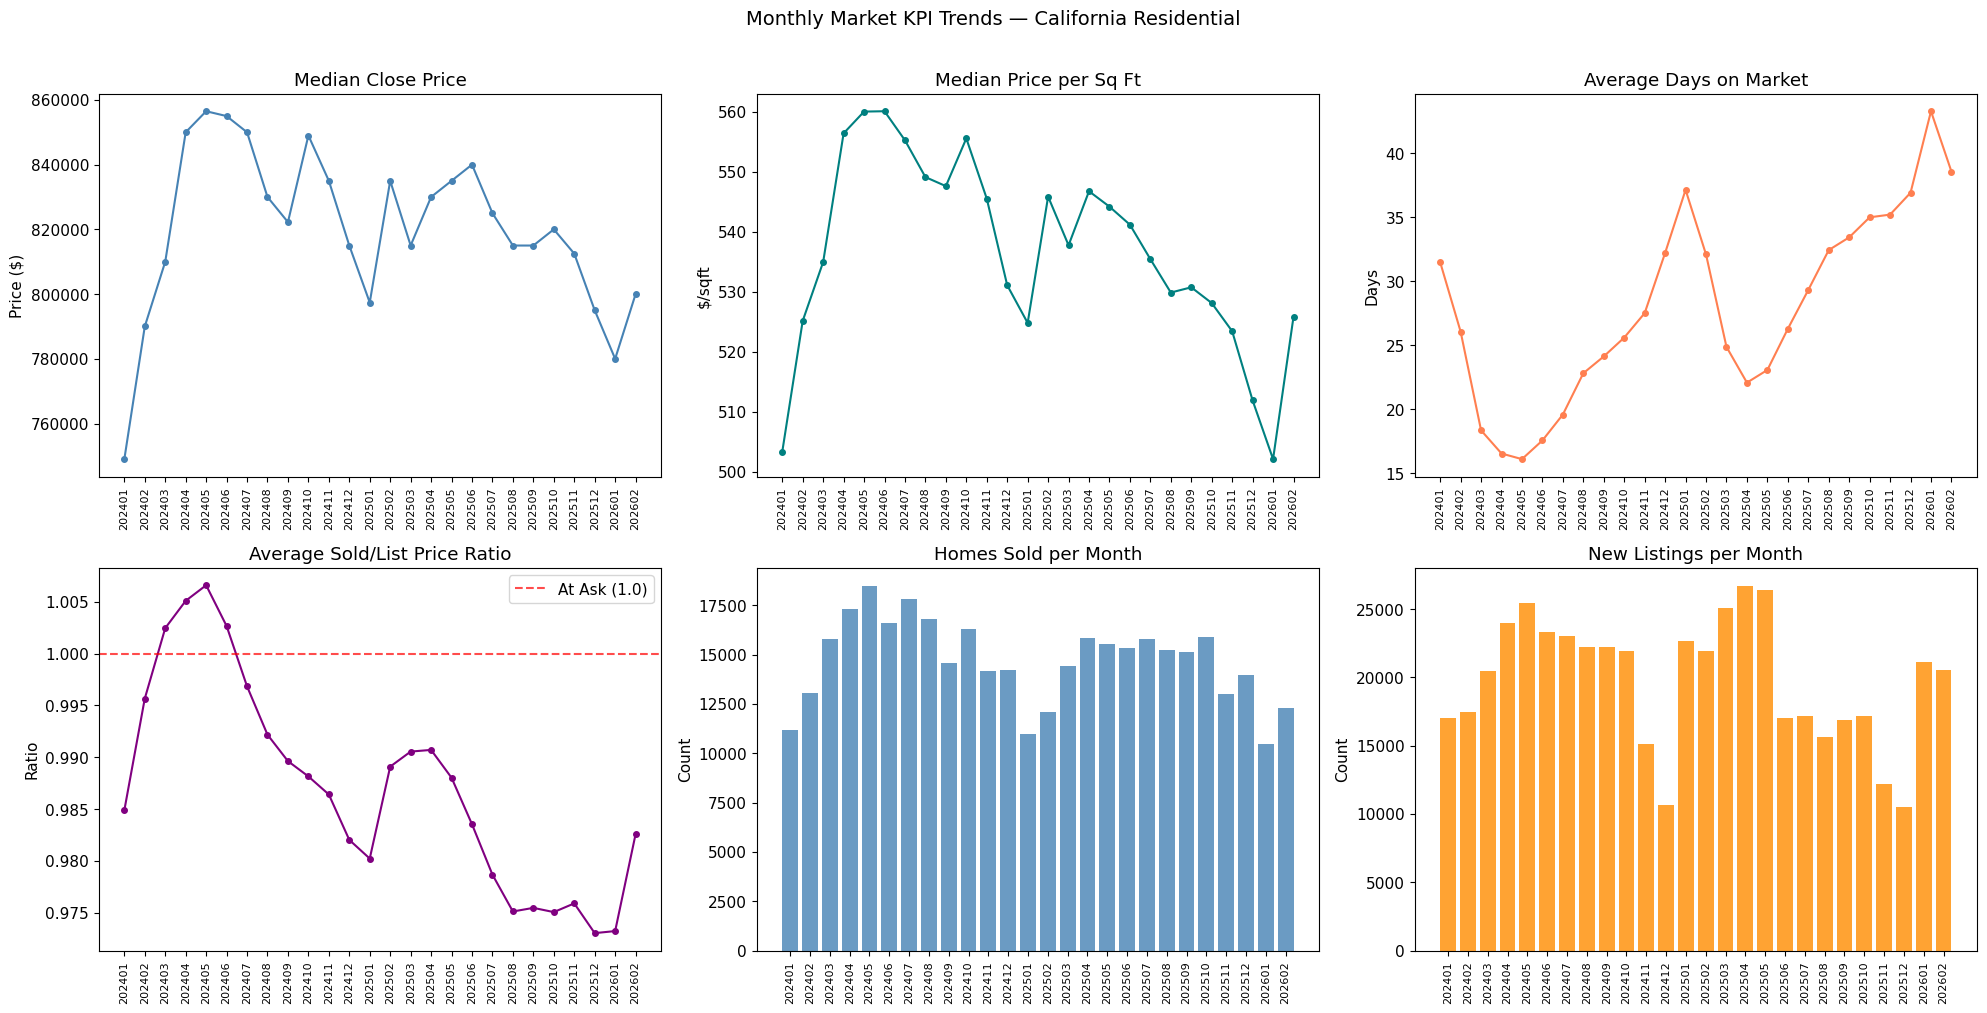

In [25]:
monthly_sold = monthly_sold_summary(sold)
monthly_listings = monthly_listing_summary(listings)
plot_monthly_kpi_trends(monthly_sold, monthly_listings)

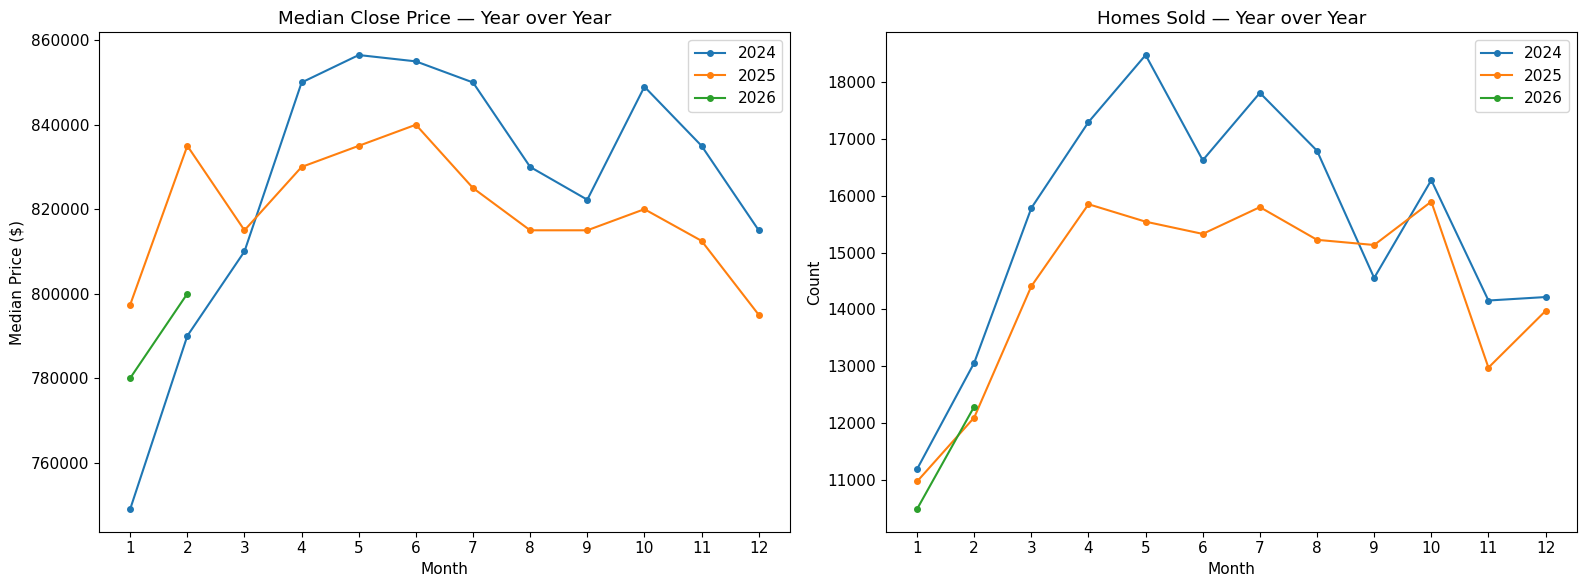

In [26]:
plot_yoy_comparison(sold)

### 6b. Supply vs. Demand

Compare new listing volume to closed sales volume over time. The ratio of these two indicates market tightness — a rising ratio means more inventory relative to demand.


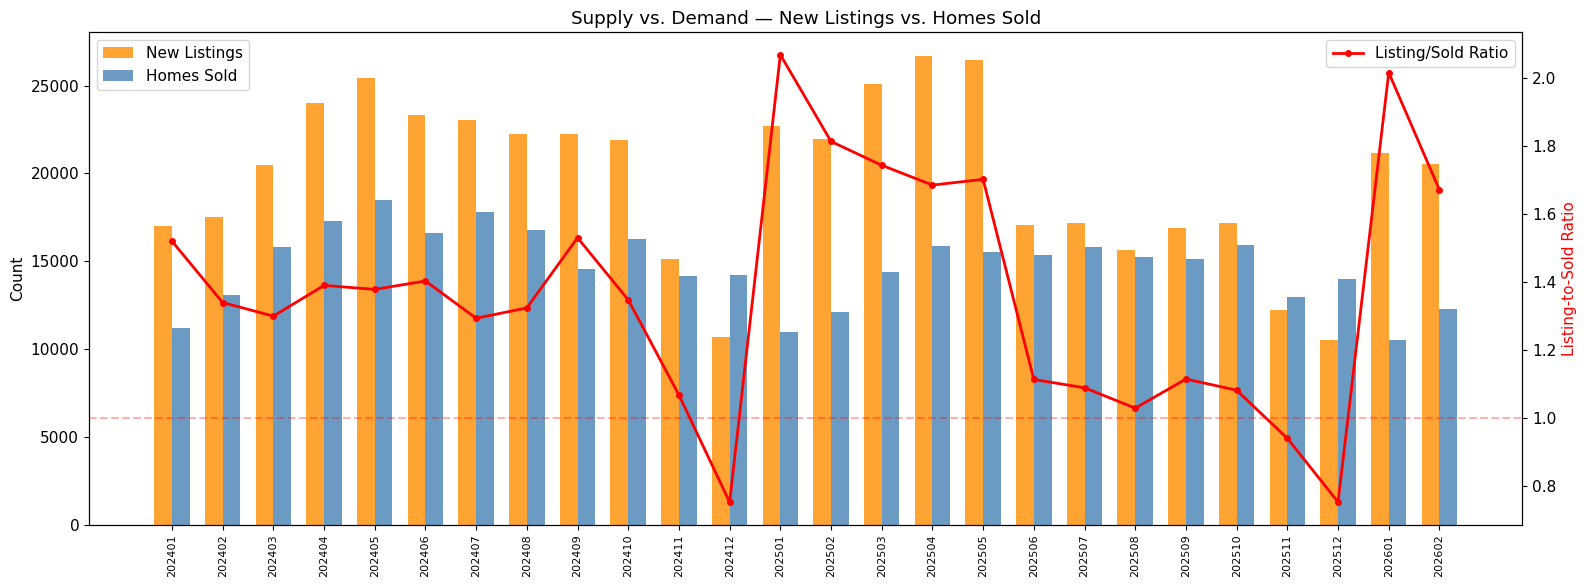

In [27]:
plot_supply_vs_demand(monthly_sold, monthly_listings)

### 6c. Geographic Analysis

Analyze market performance at the county and city level — the primary geographic dimensions used in the Tableau market analysis dashboard.


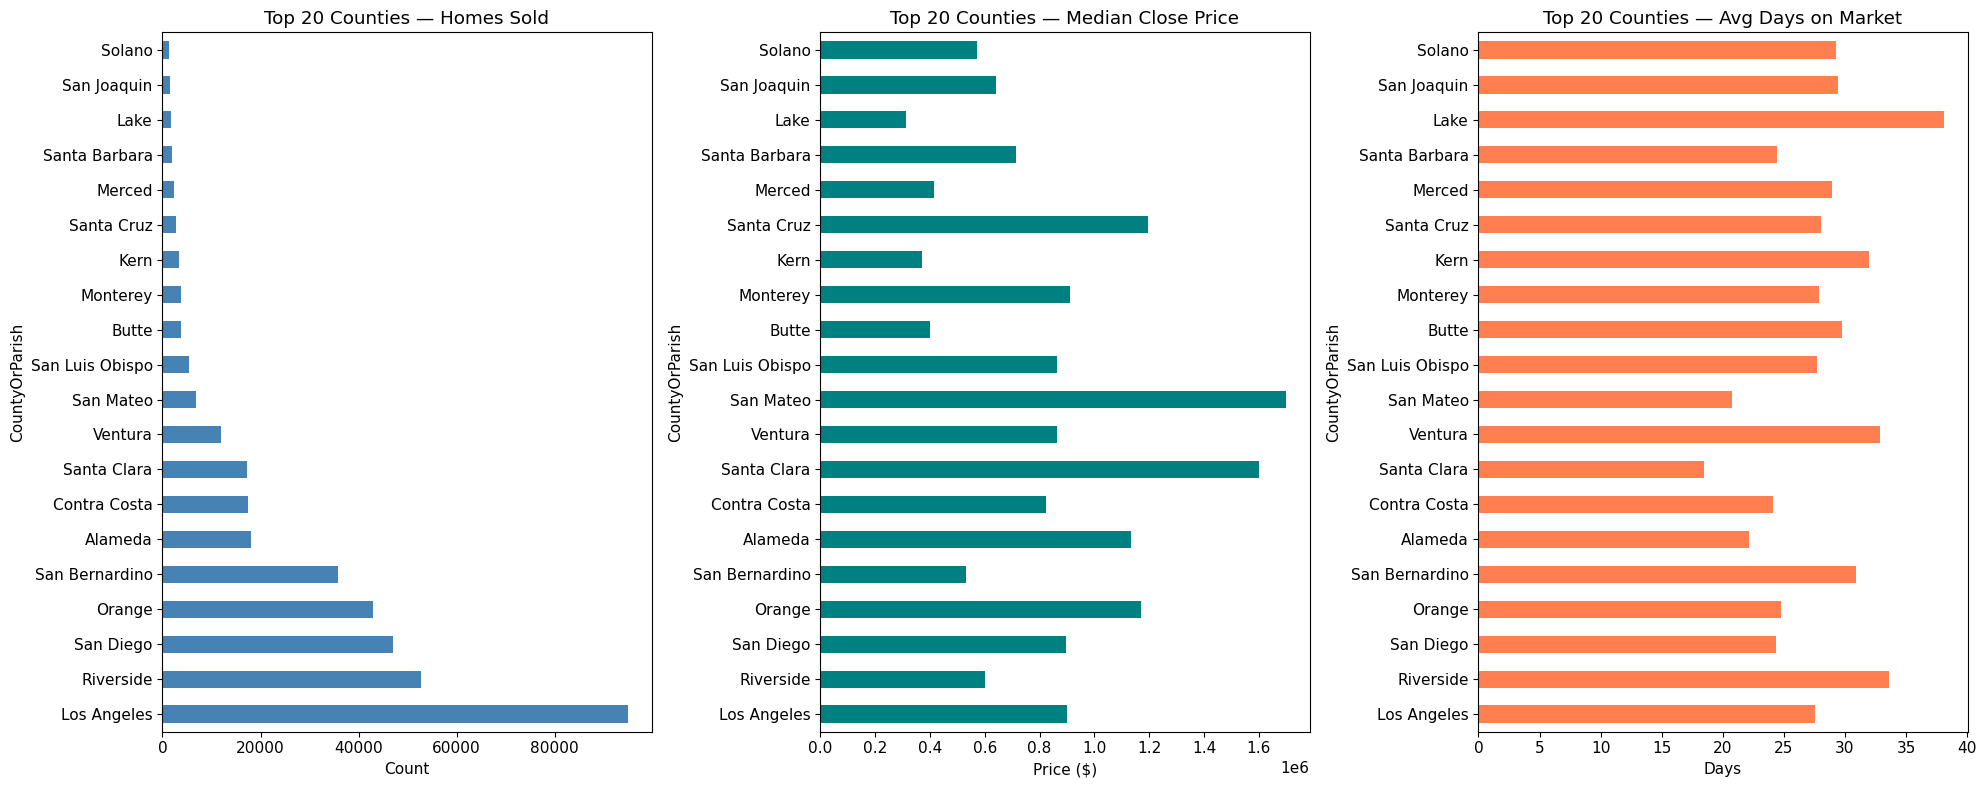

In [28]:
county_stats = geographic_summary(sold, 'CountyOrParish')
plot_top_counties(county_stats)

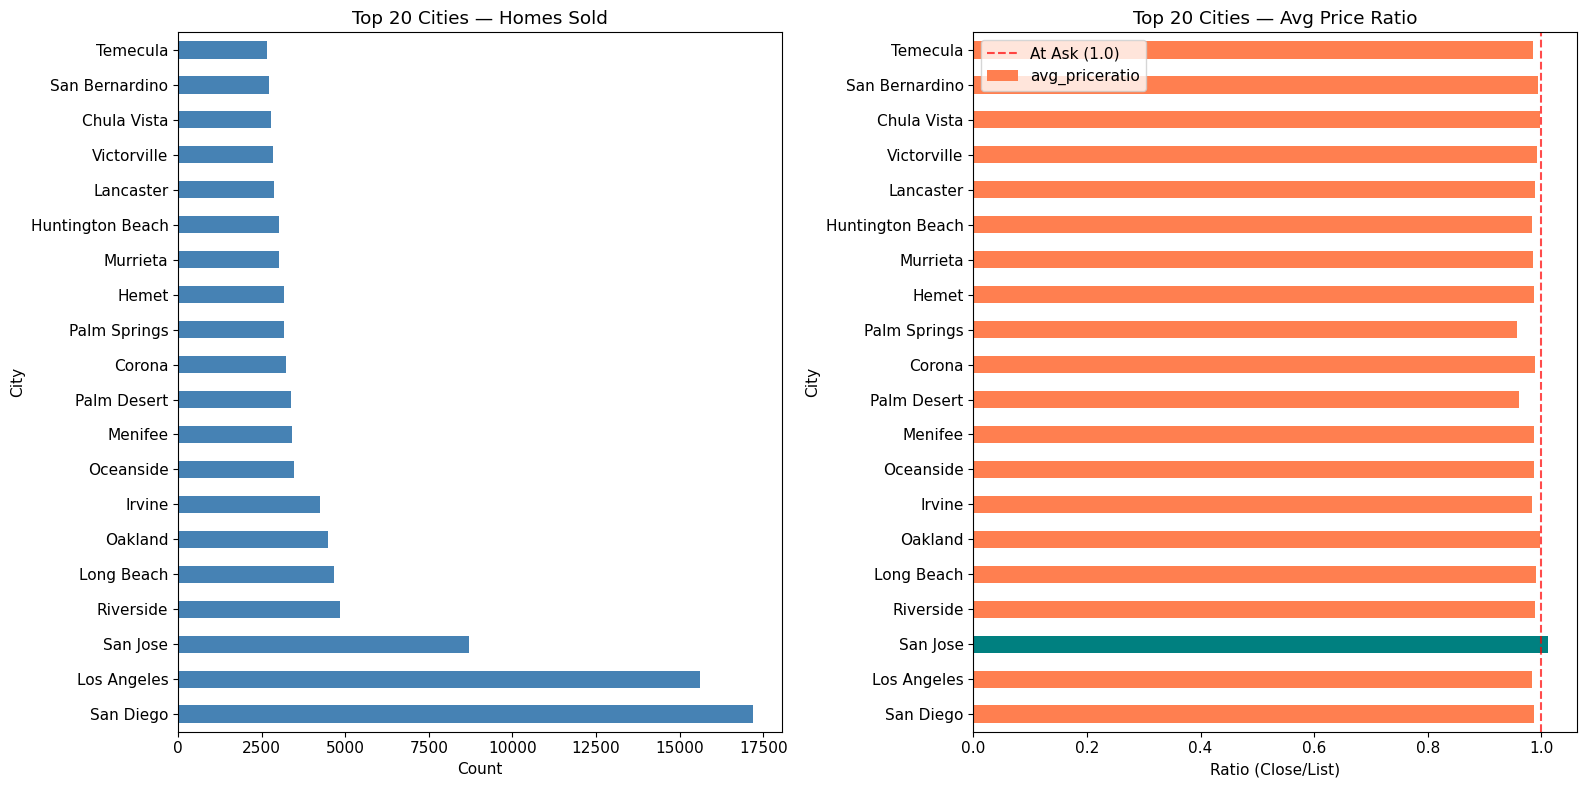

In [29]:
city_stats = geographic_summary(sold, 'City')
plot_top_cities(city_stats)

### 6d. Property Characteristics and Pricing Relationships

Explore how property attributes (size, bedrooms, year built, property subtype) relate to price and market velocity.


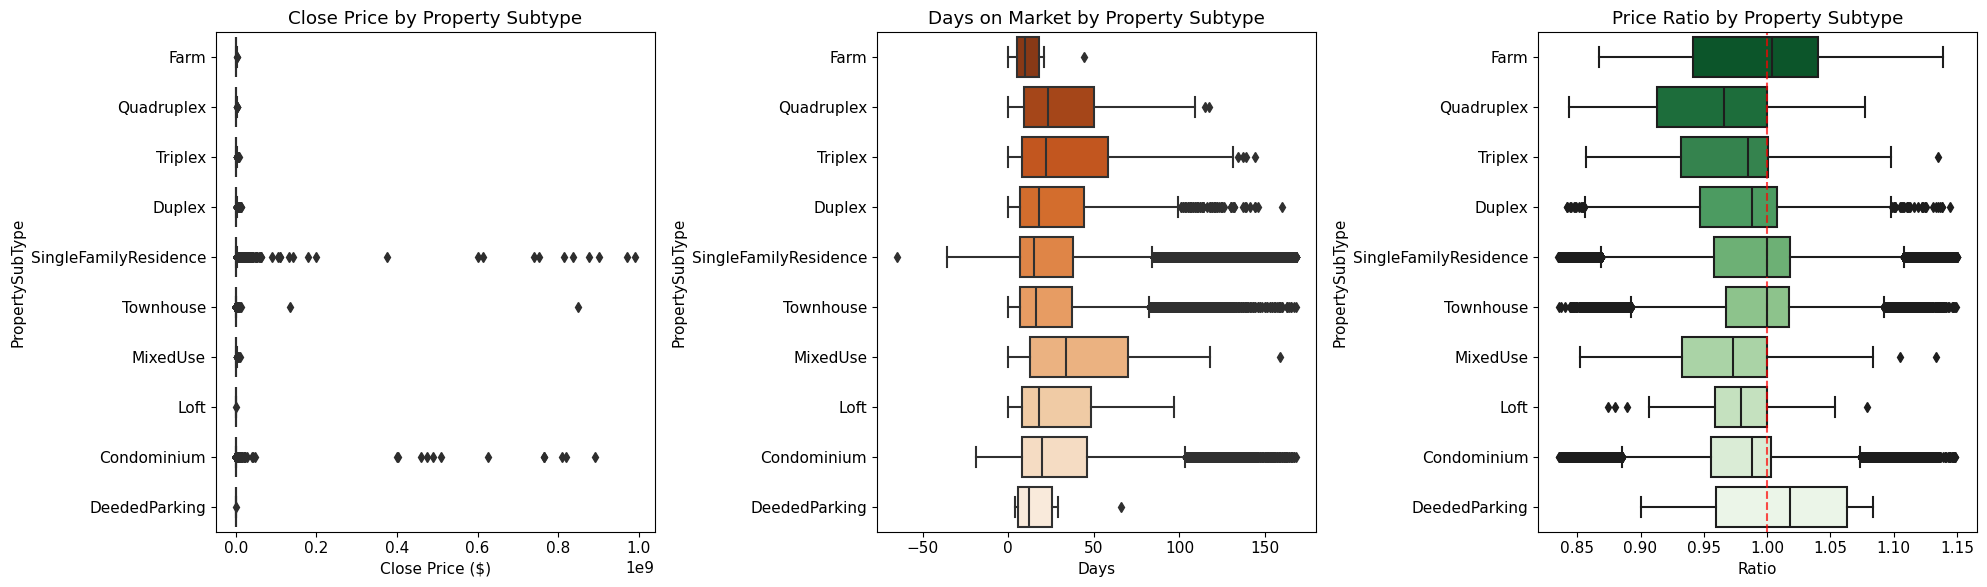

In [30]:
plot_subtype_comparison(sold)

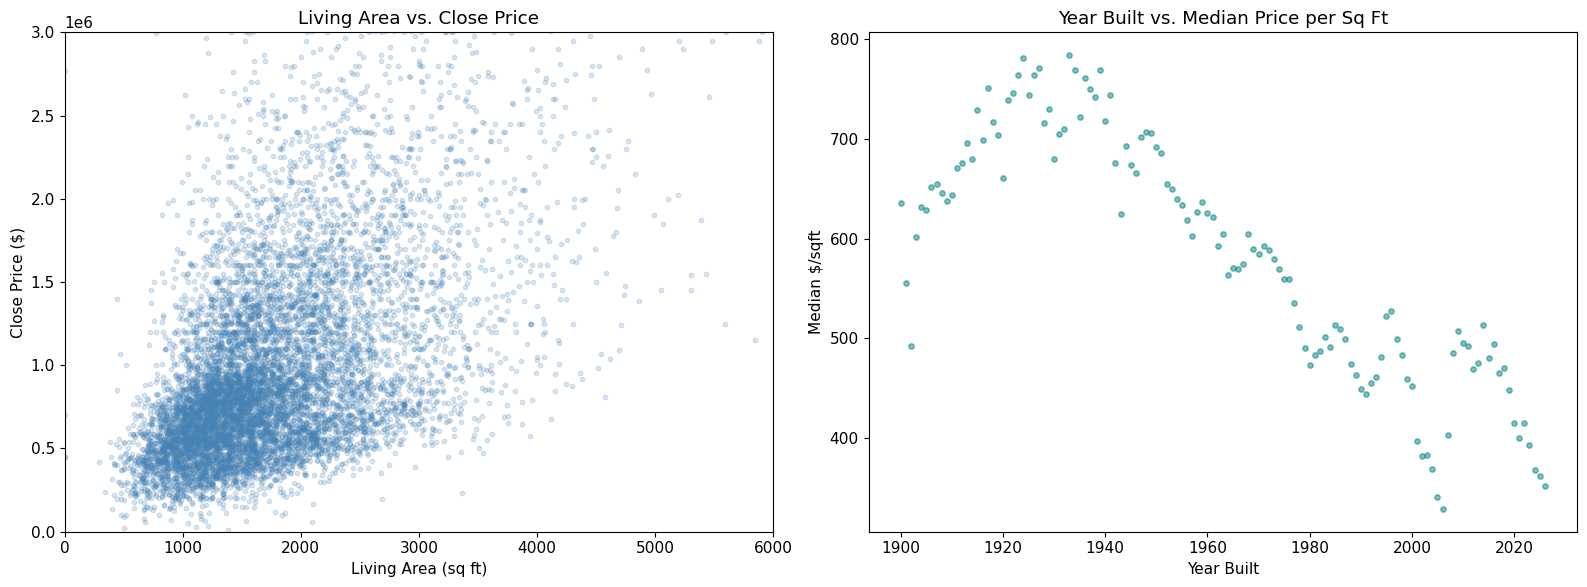

In [31]:
plot_price_vs_size(sold)

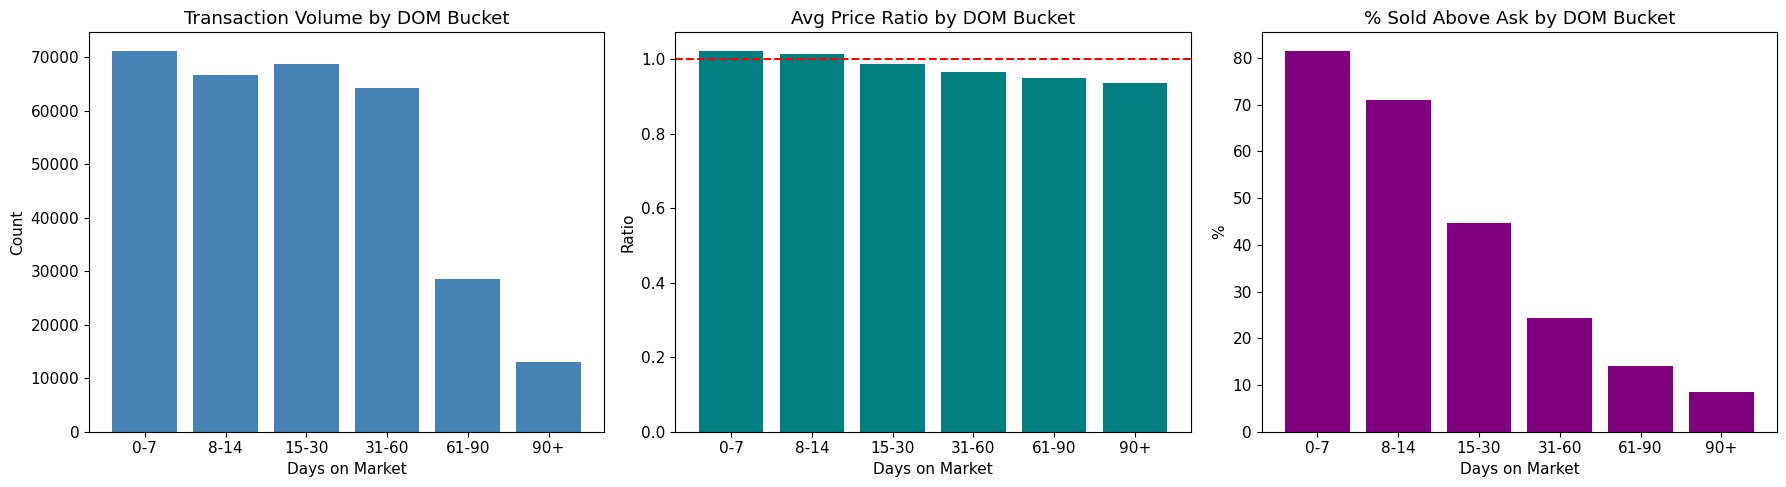

In [32]:
dom_analysis = dom_bucket_summary(sold)
plot_dom_bucket_analysis(dom_analysis)

### 6e. Price Reductions Analysis

Examine the prevalence and magnitude of price reductions across markets. High reduction rates signal softening demand — a key indicator for the market analysis dashboard.


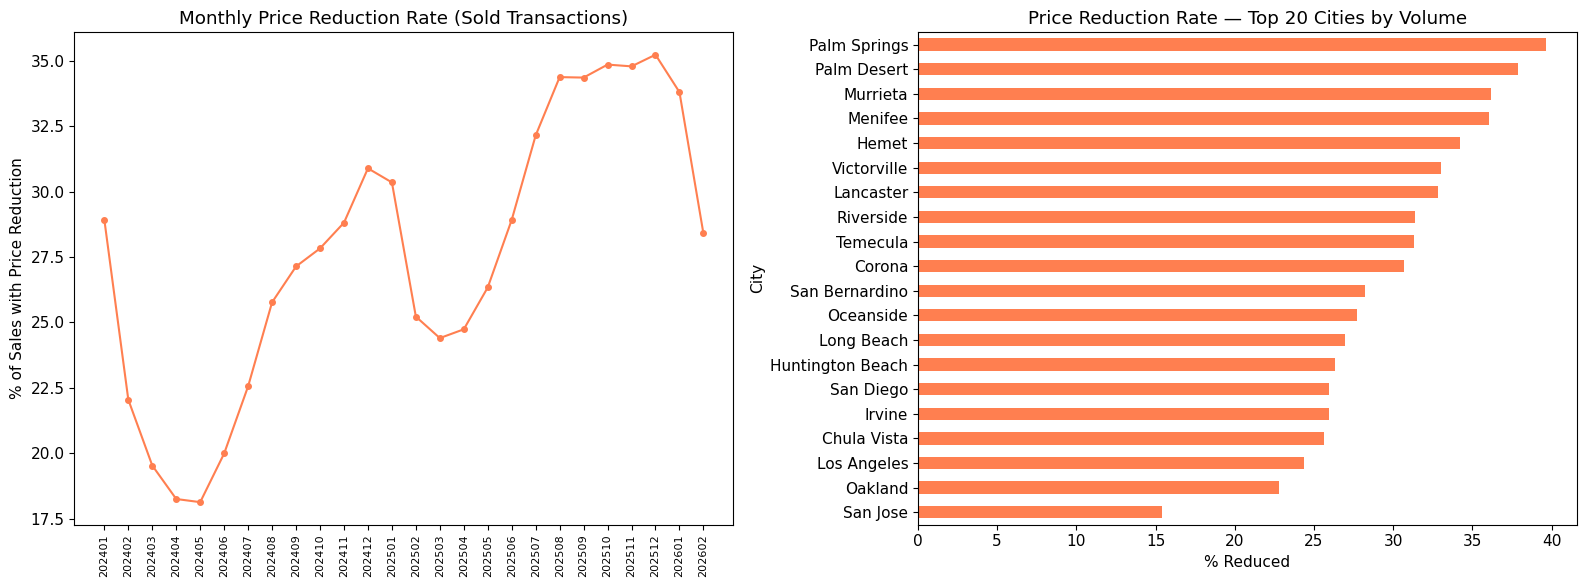

In [33]:
plot_price_reductions(sold)

### 6f. Competitive Analysis — Agent and Office Performance

Preliminary analysis of listing agent and office performance. These metrics feed directly into the Agent/Office Report Tableau dashboard.


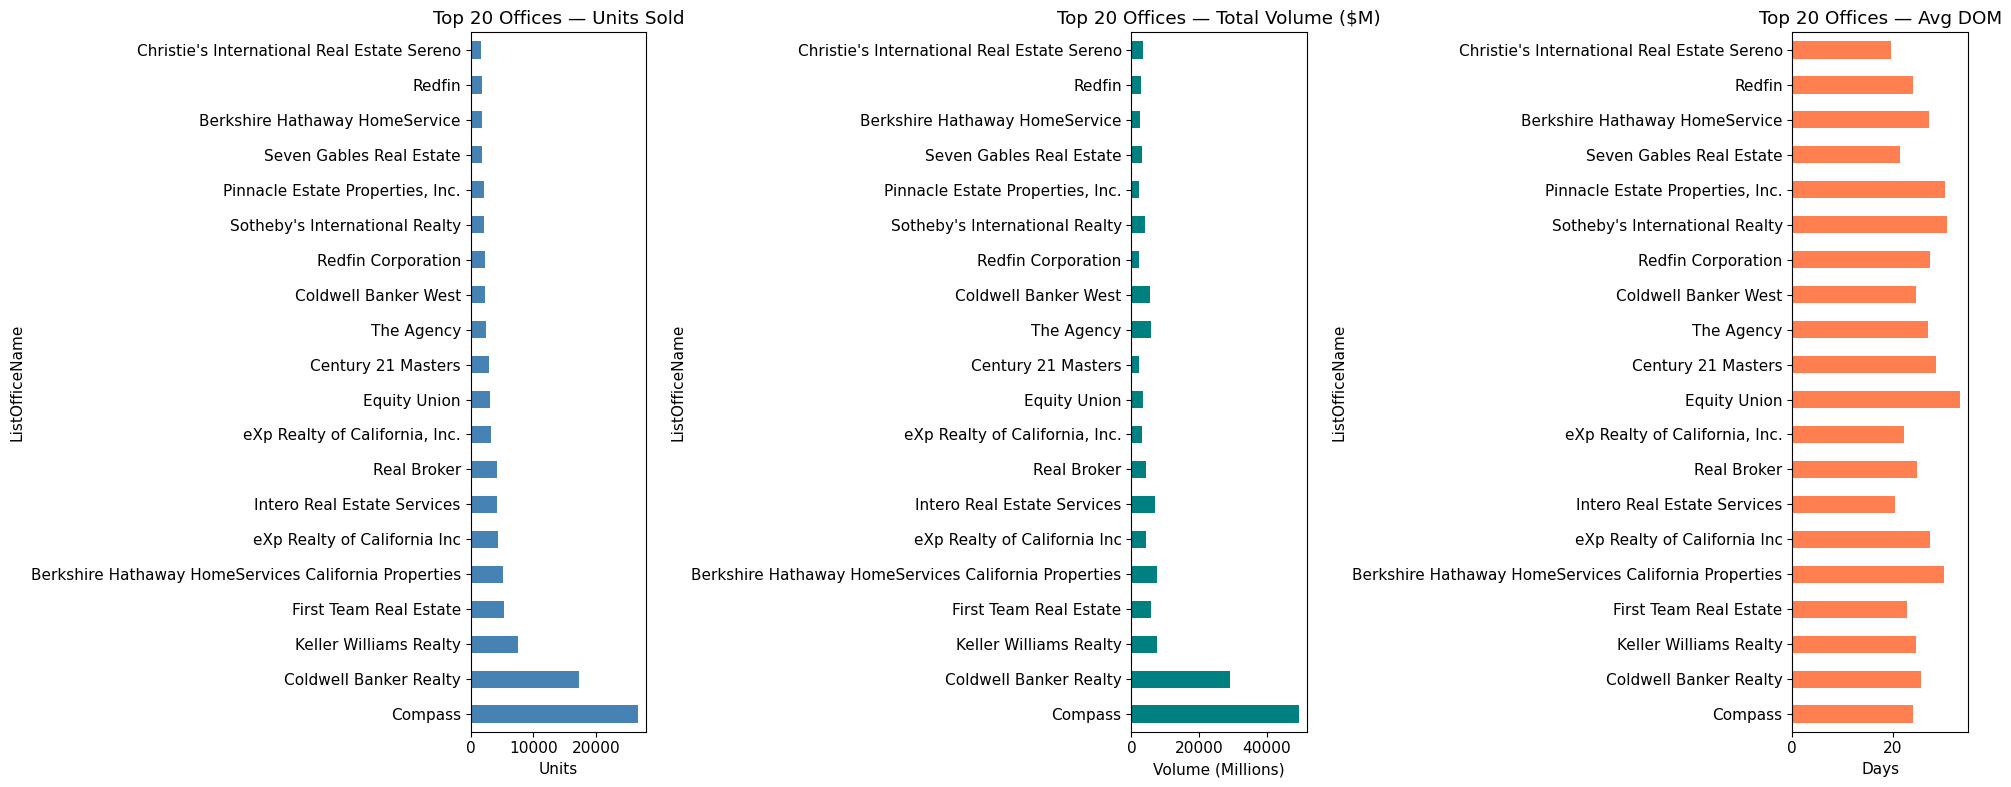

In [34]:
office_stats = competitive_summary(sold, 'ListOfficeName')
plot_top_offices(office_stats)

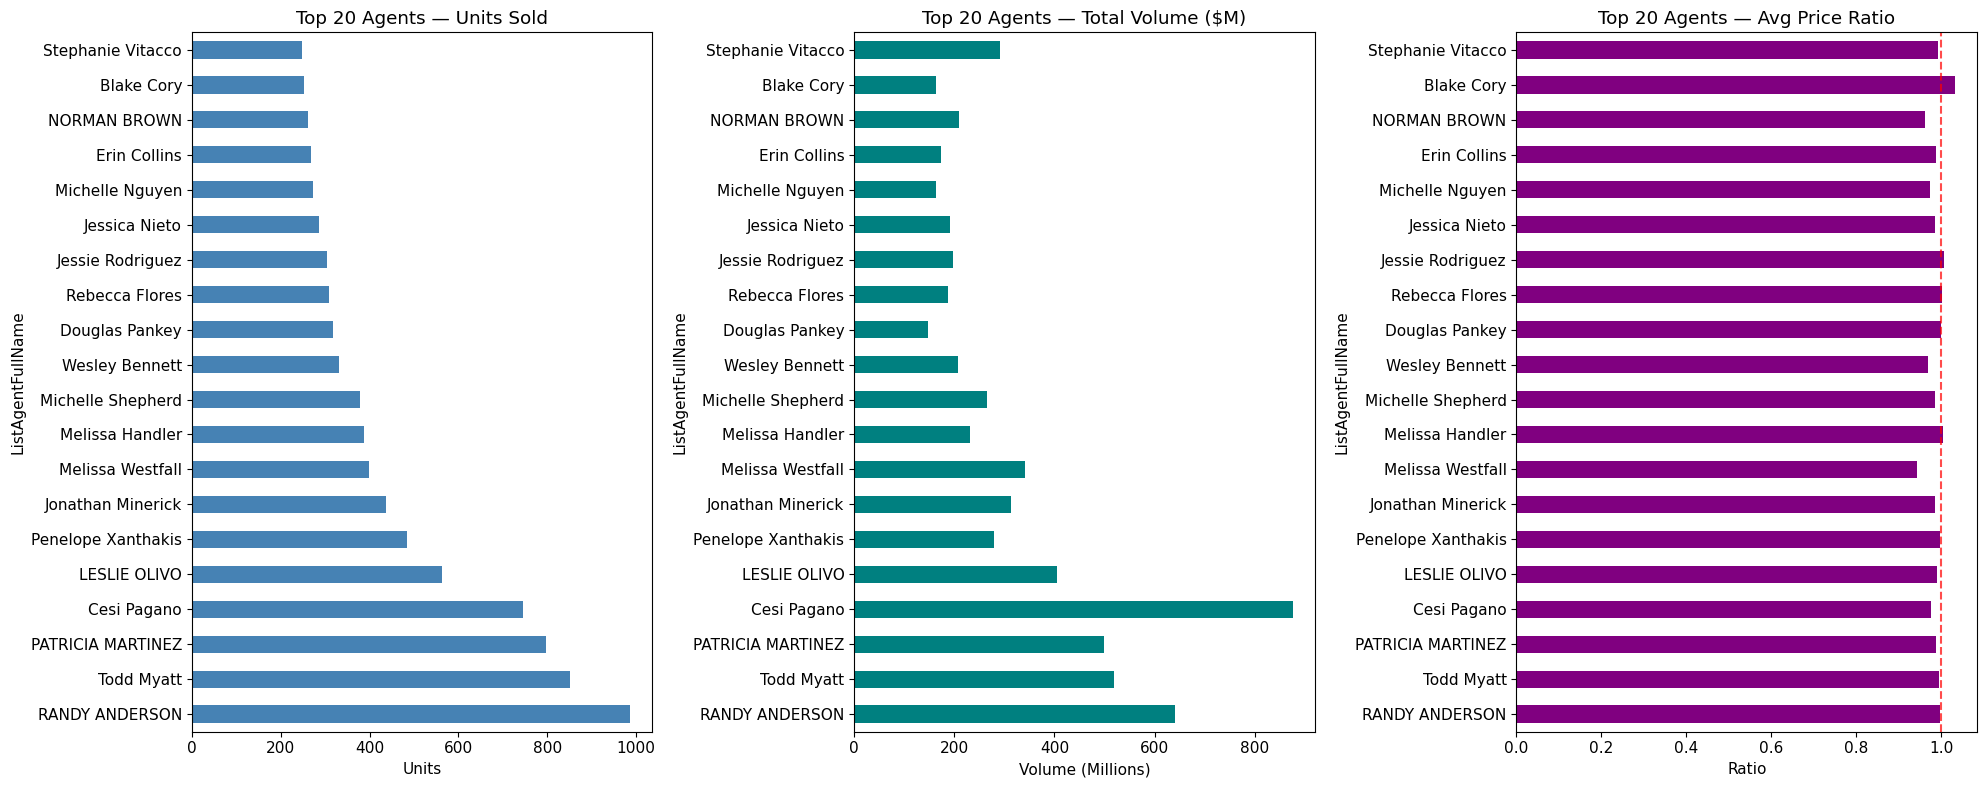

In [35]:
agent_stats = competitive_summary(sold, 'ListAgentFullName')
plot_top_agents(agent_stats)

### 6g. Correlation Analysis

Examine linear relationships between key numeric variables in the sold dataset to identify which features are most predictive of price, market velocity, and competitiveness.


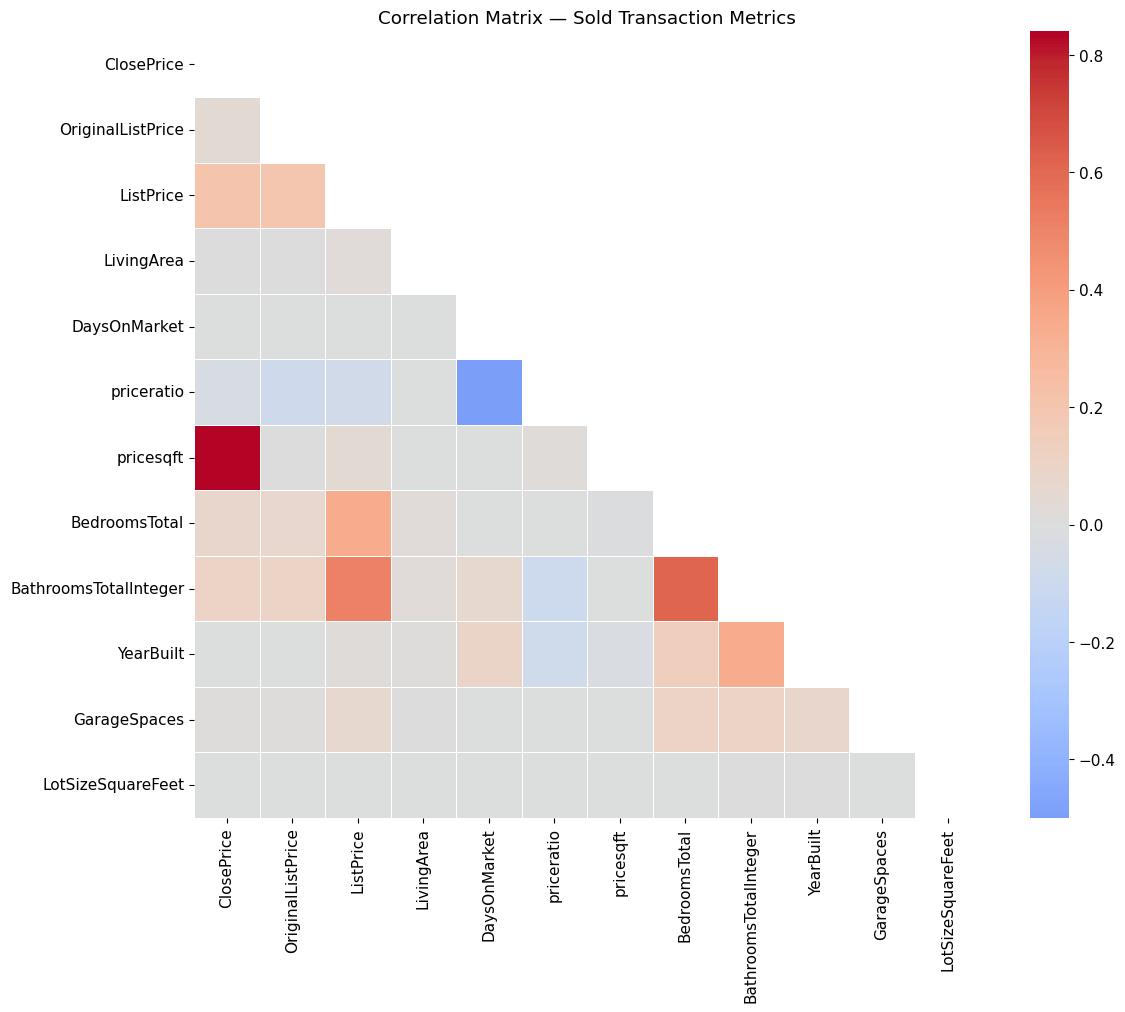

In [36]:
plot_correlation_heatmap(sold)

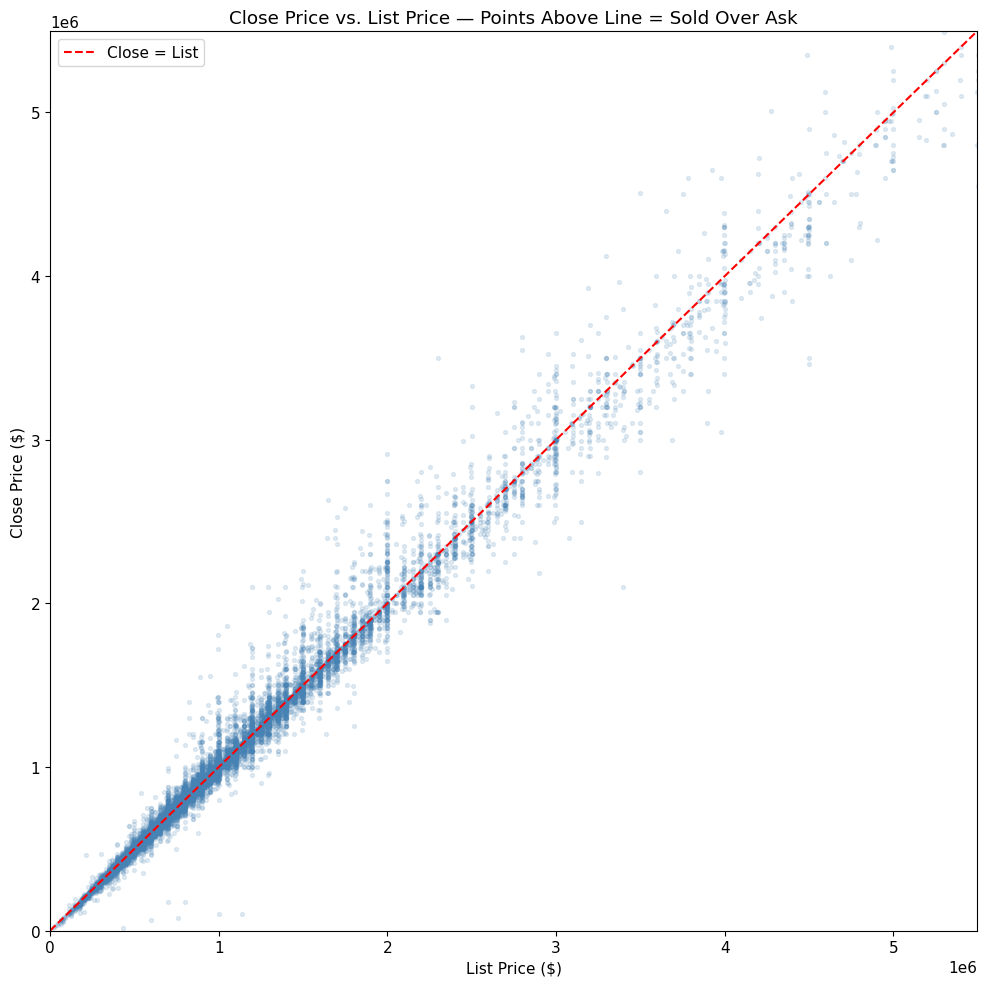

In [37]:
plot_close_vs_list(sold)

### 6h. Price Tier Analysis

Break down key metrics by price segment to understand how market dynamics differ across price points.


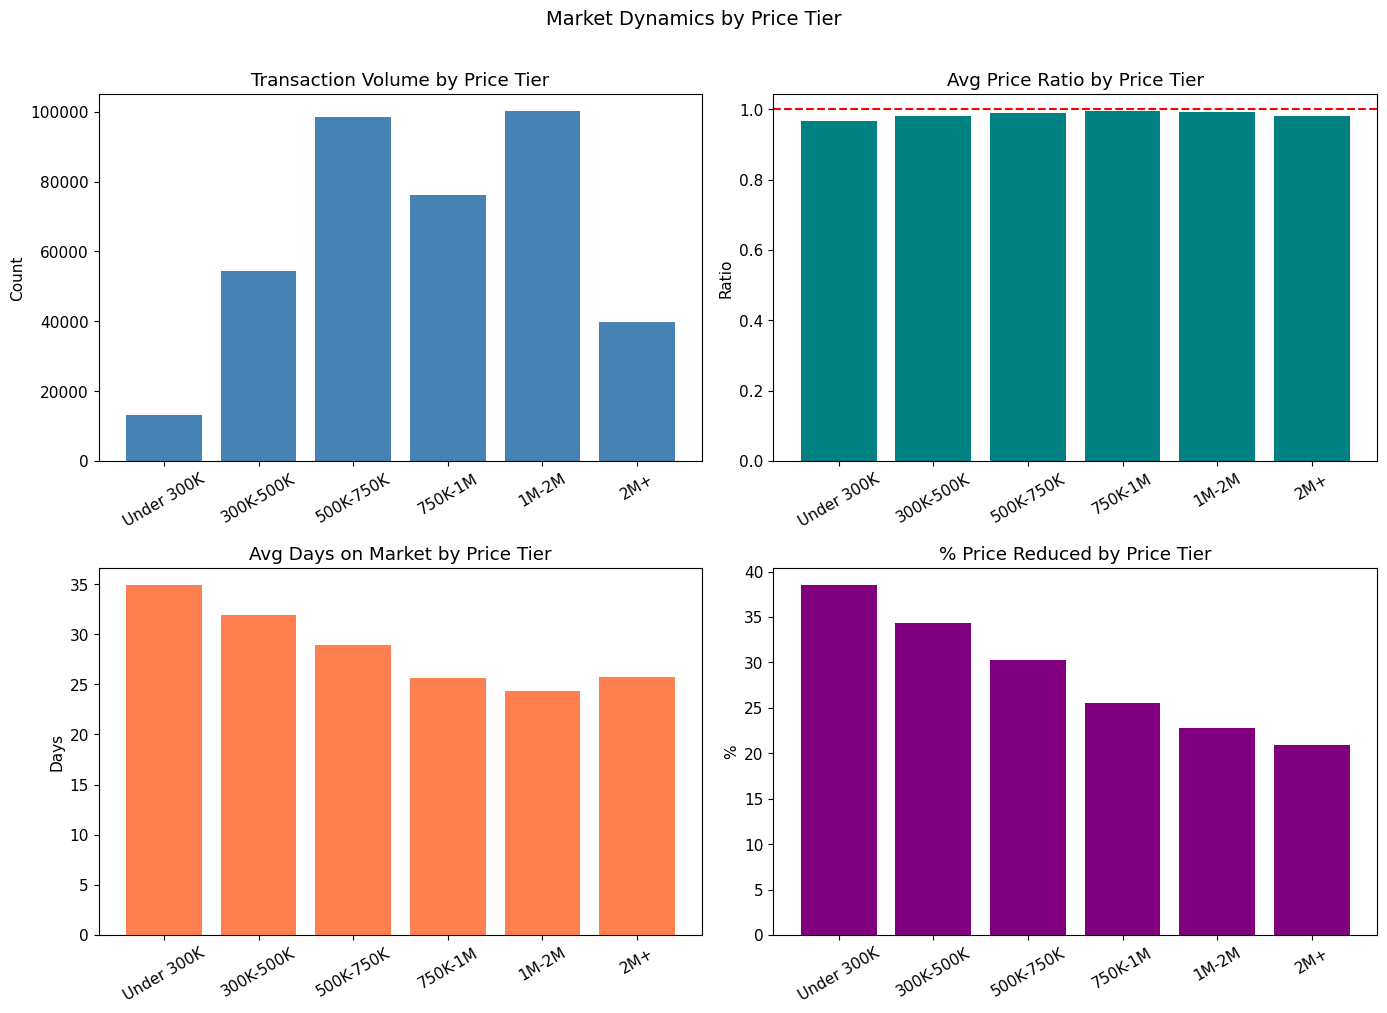

In [38]:
tier_stats = price_tier_summary(sold)
plot_price_tiers(tier_stats)

### 6i. New Construction vs. Existing Homes

New Construction vs. Existing Homes:
                    count  median_price  median_pricesqft  avg_dom  avg_priceratio
NewConstructionYN                                                                 
False              339505     825000.00            544.02    26.89            0.99
True                14437     665347.00            348.99    36.43            0.99


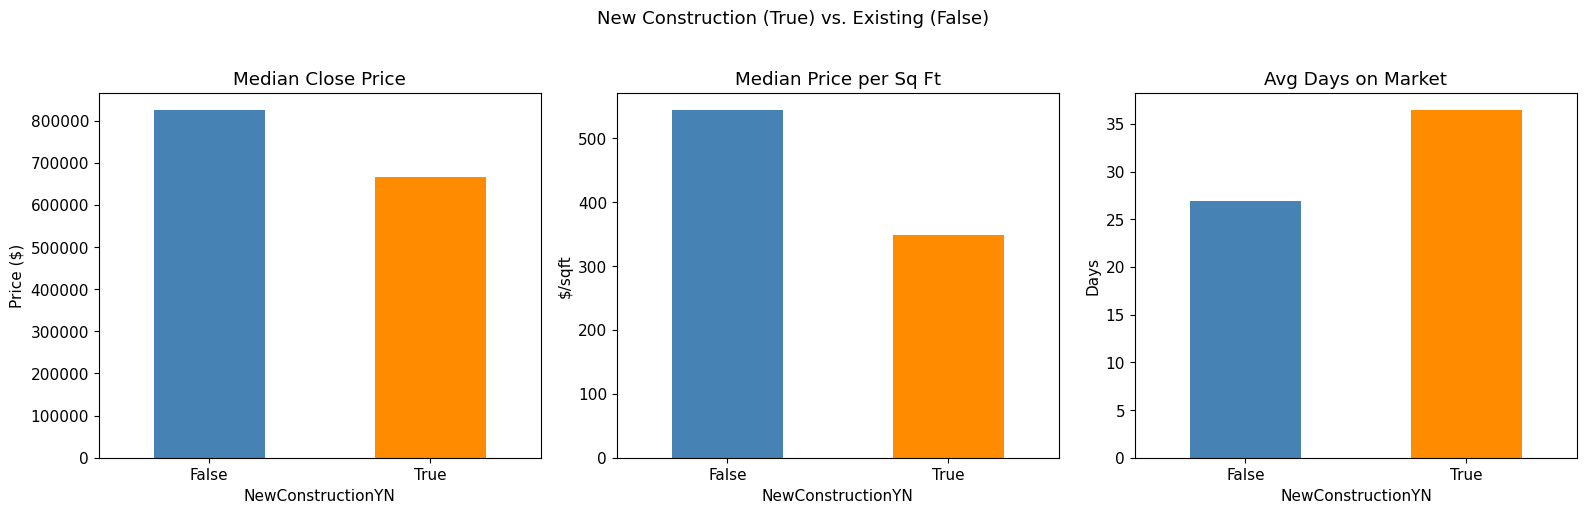

In [39]:
plot_new_construction(sold)

---
## 7. Summary Statistics for Tableau

Generate a concise summary table of the key metrics that will populate the Tableau dashboards.


In [40]:
market_summary(sold, listings)

CALIFORNIA RESIDENTIAL MARKET SUMMARY
Period: 2024-01-01 to 2026-02-28
Total closed transactions:    382,247
Total new listings:           514,182
Median close price:           $821,000
Median price per sq ft:       $538
Avg days on market:           27.3
Avg sold/list price ratio:    0.9878
% sold above ask:             44.3%
% with price reduction:       27.3%
Unique cities:                1120
Unique counties:              63
Unique ZIP codes:             3506
Unique listing offices:       18139
Unique listing agents:        75652


---
## 8. Key Findings

### Market Trends
- **Median close price is \,000** across all 27 months -- California's residential market remains firmly high-priced.
- **Average sold/list ratio of 0.9878** means the typical home sells ~1.2% below ask. However, **44.2% of transactions close at or above asking price**, indicating a split market.
- **Average DOM of 27.3 days**, with the median at 16 days. The right-skewed distribution confirms **median is the correct aggregation for DOM in Tableau**.
- Monthly KPI trends show **clear seasonality**: price peaks in late spring/summer, troughs in winter.

### Supply vs. Demand
- **539,777 new listings vs. 397,887 closed transactions**. Listing-to-sold ratio of ~1.36:1.
- The ratio trend line is a leading indicator for price direction.

### Geographic Patterns
- **63 counties and 1,123 cities** represented, confirming statewide coverage.
- Median price and DOM vary significantly by county — geographic segmentation is essential.

### Price Ratio and DOM Insights
- **DaysOnMarket and priceratio have the strongest negative correlation at -0.50** — the most actionable relationship in the dataset. Faster sales command premiums.
- Homes selling in 0-7 days have the highest average price ratio; 90+ day homes sell well below ask.

### Correlation Analysis
- **ClosePrice to pricesqft (0.84):** Validates \$/sqft as the core normalization metric.
- **BathroomsTotalInteger to ListPrice (0.52):** Bathrooms are a stronger price predictor than bedrooms.
- **LotSizeSquareFeet** has near-zero correlation with everything at the statewide level.

### Price Reductions
- **27.2% of closed sales had price reductions.** City-level rates vary from <20% to >30%.

### New Construction vs. Existing
- Existing homes: median \K at \/sqft. New construction: median \K at \/sqft.
- New construction is cheaper per sqft but sits longer on market (36.5 vs 26.9 days).

### Data Quality Notes
- FireplacesTotal and CoveredSpaces are 100% null — exclude from analysis.
- BuildingAreaTotal is 93% null — use LivingArea instead.
- LivingArea max of 17M sqft indicates data entry errors; manageable with median aggregations.
- DaysOnMarket has negative values — filter or set to 0.

### Recommended Tableau Focus Areas
1. **DOM vs. Price Ratio** — strongest finding
2. **Monthly KPI trends with YOY overlay** — clear seasonality
3. **City/county-level price ratio maps** — geographic competitiveness varies dramatically
4. **Supply vs. demand time series** — leading market indicator
5. **Price reduction rate trends** — early warning for market shifts
6. **Price tier segmentation** — dynamics differ substantially by price segment
